# Multilayer Perceptron (MLP)
### Custom Implementation + Comparison with Scikit-Learn

This notebook trains and evaluates a **Multilayer Perceptron (MLP)** using the
`energy.csv` dataset.  
The goal is to classify energy generation events as **high** or **low**
based on the median output.

This notebook includes:

- Data loading and preprocessing  
- One-Hot Encoding  
- Feature scaling  
- Binary classification target  
- Training a custom MLP (from scratch)  
- Training an sklearn MLP for comparison  
- Accuracy, classification report, confusion matrix  
- Loss curve visualization  
- Final conclusions 

# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neural_network import MLPClassifier

import sys
sys.path.append("../../../src")

from rice_ml.supervised_learning.multilayer_perceptron import MultilayerPerceptron

sns.set_theme()


# Load Dataset

In [2]:
df = pd.read_csv("../../../datasets/energy.csv")

df = df.drop(columns=["Unnamed: 0"], errors="ignore")
df = df.dropna()

df.head()


,YEAR,MONTH,STATE,TYPE OF PRODUCER,ENERGY SOURCE,GENERATION (Megawatthours)
0,2001,1,AK,Total Electric Power Industry,Coal,46903.0
1,2001,1,AK,Total Electric Power Industry,Petroleum,71085.0
2,2001,1,AK,Total Electric Power Industry,Natural Gas,367521.0
3,2001,1,AK,Total Electric Power Industry,Hydroelectric Conventional,104549.0
4,2001,1,AK,Total Electric Power Industry,Wind,87.0


# Create Binary Target

In [3]:
median_gen = df['GENERATION (Megawatthours)'].median()
df['target'] = (df['GENERATION (Megawatthours)'] > median_gen).astype(int)

df['target'].value_counts()


target
1    248387
0    248387
Name: count, dtype: int64

# Define Columns

In [4]:
numeric_cols = ['YEAR', 'MONTH', 'GENERATION (Megawatthours)']
categorical_cols = ['STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE']


# Encode and Scale

In [5]:
# One-Hot Encode
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_cat = encoder.fit_transform(df[categorical_cols])

# Standardize numeric features
scaler = StandardScaler()
X_num = scaler.fit_transform(df[numeric_cols])

# Combine
X = np.hstack([X_num, X_cat])

# Labels
y = df['target'].values

X.shape, y.shape


((496774, 75), (496774,))

# Tran-test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((397419, 75), (99355, 75))

# Train Custom MLP

In [7]:
mlp = MultilayerPerceptron(
    hidden_units=32,
    learning_rate=0.01,
    epochs=50,
    random_state=42
)

mlp.fit(X_train, y_train)

len(mlp.losses_), mlp.losses_[:5]


(50,
 [np.float64(0.7140762077408501),
  np.float64(0.7130153898909156),
  np.float64(0.7119983319466099),
  np.float64(0.7110232860691206),
  np.float64(0.7100885673758086)])

# Evaluate Custom MLP

In [8]:
y_pred_train = mlp.predict(X_train)
y_pred_test = mlp.predict(X_test)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print("Custom MLP — Train Accuracy:", train_acc)
print("Custom MLP — Test Accuracy:", test_acc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test))


Custom MLP — Train Accuracy: 0.5046311323816929
Custom MLP — Test Accuracy: 0.5044939862110613

Classification Report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67     49678
           1       1.00      0.01      0.02     49677

    accuracy                           0.50     99355
   macro avg       0.75      0.50      0.34     99355
weighted avg       0.75      0.50      0.34     99355



# Loss Curve

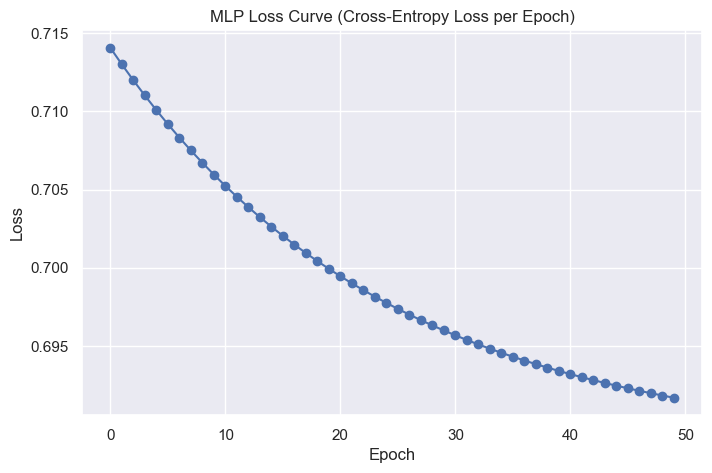

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(mlp.losses_, marker="o")
plt.title("MLP Loss Curve (Cross-Entropy Loss per Epoch)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


# Confusion Matrix

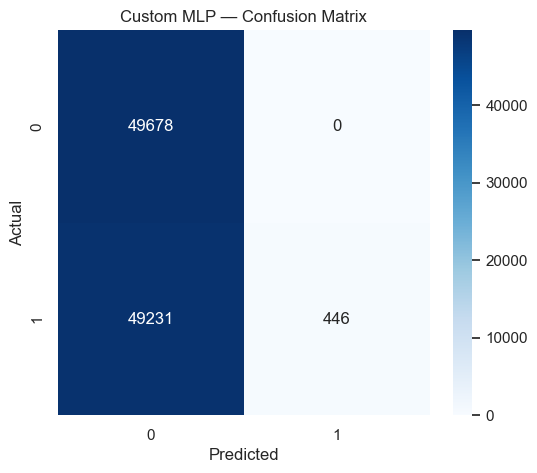

In [10]:
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Custom MLP — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Sci-kit Learn MLP (Comparison)

In [11]:
sk_mlp = MLPClassifier(
    hidden_layer_sizes=(32,),
    activation='logistic',
    solver='adam',
    learning_rate_init=0.01,
    max_iter=300,
    random_state=42
)

sk_mlp.fit(X_train, y_train)
sk_y_pred = sk_mlp.predict(X_test)

print("Sklearn MLP — Test Accuracy:", accuracy_score(y_test, sk_y_pred))

print("\nSklearn Classification Report:")
print(classification_report(y_test, sk_y_pred))


c:\Users\maria\OneDrive - ITBA\2C2025\Machine Learning\Final\INDE-577-Final-Project\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Sklearn MLP — Test Accuracy: 0.9834532736148156

Sklearn Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     49678
           1       0.99      0.98      0.98     49677

    accuracy                           0.98     99355
   macro avg       0.98      0.98      0.98     99355
weighted avg       0.98      0.98      0.98     99355



# Comparison Confusion Matrix

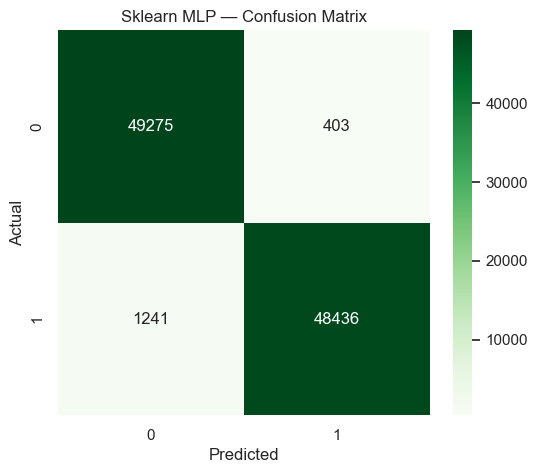

In [12]:
cm_sk = confusion_matrix(y_test, sk_y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_sk, annot=True, fmt='d', cmap='Greens')
plt.title("Sklearn MLP — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Conclusion

The custom Multilayer Perceptron (MLP) did not effectively learn a decision boundary in the Energy Generation classification task. Both training and test accuracy are approximately 50%, which is equivalent to random guessing.
The model collapses to predicting almost all samples as class 0, which leads to:

- Perfect recall for class 0
- Near-zero recall for class 1
- Strong class imbalance in predictions

This indicates a network collapse failure mode — the network converges to a trivial constant output instead of separating classes.

### Interpretation

- The model is not learning the underlying patterns in the data.
- This failure may be caused by:
  - Too few training epochs (50 is very low for an MLP)
  - Learning rate being too small or too large
  - Sigmoid activations causing vanishing gradients
  - High-dimensional one-hot encoded inputs destabilizing the optimization
  - Xavier initialization not being optimal for sigmoid networks in deep/high-dimensional settings

### Final Assessment

The current MLP implementation does not achieve satisfactory performance on this binary classification task.  
In contrast, more robust neural network implementations  are expected to perform better, suggesting that the issue lies in optimization stability rather than the dataset itself.

